## Introduction

Water pollution is a critical global issue that affects public health, ecosystems, and socio-economic development. Contaminated water sources can lead to the spread of waterborne diseases, reduced access to clean drinking water, and adverse impacts on communities, particularly in developing regions. Understanding the relationship between water quality, pollution levels, and their socio-economic and health implications is essential for informed decision-making and policy development.

This analysis leverages a comprehensive dataset to explore various aspects of water quality and its impact on public health. By examining metrics such as contaminant levels, pH, turbidity, and access to clean water, alongside health indicators like disease incidence and infant mortality rates, this study aims to uncover trends, disparities, and correlations. Additionally, socio-economic factors such as GDP per capita and sanitation coverage are analyzed to provide a holistic view of the issue.

The insights derived from this analysis can help identify regions and populations most at risk, evaluate the effectiveness of water treatment methods, and guide interventions to improve water quality and public health outcomes.

import necessary libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import dataset

In [6]:
df=pd.read_csv(r'C:\Users\rayde\Downloads\water_pollution_disease.csv')
print(df)

        Country   Region  Year Water Source Type  Contaminant Level (ppm)  \
0        Mexico    North  2015              Lake                     6.06   
1        Brazil     West  2017              Well                     5.24   
2     Indonesia  Central  2022              Pond                     0.24   
3       Nigeria     East  2016              Well                     7.91   
4        Mexico    South  2005              Well                     0.12   
...         ...      ...   ...               ...                      ...   
2995    Nigeria     East  2002               Tap                     2.82   
2996    Nigeria    North  2019              Lake                     8.13   
2997        USA    South  2009              Pond                     1.18   
2998   Pakistan    South  2009              Pond                     7.56   
2999     Mexico    North  2013            Spring                     0.98   

      pH Level  Turbidity (NTU)  Dissolved Oxygen (mg/L)  \
0         7.12 

Display first and last 10 rows of the dataset

In [7]:
print(df.head(10))

     Country   Region  Year Water Source Type  Contaminant Level (ppm)  \
0     Mexico    North  2015              Lake                     6.06   
1     Brazil     West  2017              Well                     5.24   
2  Indonesia  Central  2022              Pond                     0.24   
3    Nigeria     East  2016              Well                     7.91   
4     Mexico    South  2005              Well                     0.12   
5   Ethiopia     West  2013               Tap                     2.93   
6      China     East  2022             River                     0.06   
7     Mexico  Central  2024            Spring                     3.76   
8  Indonesia    North  2014              Well                     0.63   
9    Nigeria  Central  2013              Well                     9.14   

   pH Level  Turbidity (NTU)  Dissolved Oxygen (mg/L)  Nitrate Level (mg/L)  \
0      7.12             3.93                     4.28                  8.28   
1      7.84             4.7

In [8]:
print(df.tail(10))

       Country   Region  Year Water Source Type  Contaminant Level (ppm)  \
2990  Pakistan     East  2016               Tap                     3.64   
2991     China  Central  2021             River                     0.80   
2992       USA     East  2006              Pond                     8.87   
2993    Mexico     West  2009              Well                     1.98   
2994  Ethiopia  Central  2010              Lake                     7.49   
2995   Nigeria     East  2002               Tap                     2.82   
2996   Nigeria    North  2019              Lake                     8.13   
2997       USA    South  2009              Pond                     1.18   
2998  Pakistan    South  2009              Pond                     7.56   
2999    Mexico    North  2013            Spring                     0.98   

      pH Level  Turbidity (NTU)  Dissolved Oxygen (mg/L)  \
2990      6.29             2.43                     4.71   
2991      7.01             4.80            

In [9]:
df.shape

(3000, 24)

In [10]:
df.columns

Index(['Country', 'Region', 'Year', 'Water Source Type',
       'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
       'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)',
       'Water Treatment Method', 'Access to Clean Water (% of Population)',
       'Diarrheal Cases per 100,000 people',
       'Cholera Cases per 100,000 people', 'Typhoid Cases per 100,000 people',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)'],
      dtype='object')

Data cleaning

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3000 non-null   object 
 1   Region                                         3000 non-null   object 
 2   Year                                           3000 non-null   int64  
 3   Water Source Type                              3000 non-null   object 
 4   Contaminant Level (ppm)                        3000 non-null   float64
 5   pH Level                                       3000 non-null   float64
 6   Turbidity (NTU)                                3000 non-null   float64
 7   Dissolved Oxygen (mg/L)                        3000 non-null   float64
 8   Nitrate Level (mg/L)                           3000 non-null   float64
 9   Lead Concentration (µg/L)                      3000 

In [12]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   country                                     3000 non-null   object 
 1   region                                      3000 non-null   object 
 2   year                                        3000 non-null   int64  
 3   water_source_type                           3000 non-null   object 
 4   contaminant_level_ppm                       3000 non-null   float64
 5   ph_level                                    3000 non-null   float64
 6   turbidity_ntu                               3000 non-null   float64
 7   dissolved_oxygen_mgl                        3000 non-null   float64
 8   nitrate_level_mgl                           3000 non-null   float64
 9   lead_concentration_gl                       3000 non-null   float64
 10  bacteria_cou

In [14]:
df.describe(include='object')

,country,region,water_source_type,water_treatment_method
count,3000,3000,3000,3000
unique,10,5,6,4
top,USA,East,River,Boiling
freq,319,625,538,777


In [15]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

country
['Mexico' 'Brazil' 'Indonesia' 'Nigeria' 'Ethiopia' 'China' 'Bangladesh'
 'India' 'USA' 'Pakistan']
--------------------------------------------------
region
['North' 'West' 'Central' 'East' 'South']
--------------------------------------------------
water_source_type
['Lake' 'Well' 'Pond' 'Tap' 'River' 'Spring']
--------------------------------------------------
water_treatment_method
['Filtration' 'Boiling' 'None' 'Chlorination']
--------------------------------------------------


In [16]:
df.isnull().sum()

country                                       0
region                                        0
year                                          0
water_source_type                             0
contaminant_level_ppm                         0
ph_level                                      0
turbidity_ntu                                 0
dissolved_oxygen_mgl                          0
nitrate_level_mgl                             0
lead_concentration_gl                         0
bacteria_count_cfuml                          0
water_treatment_method                        0
access_to_clean_water__of_population          0
diarrheal_cases_per_100000_people             0
cholera_cases_per_100000_people               0
typhoid_cases_per_100000_people               0
infant_mortality_rate_per_1000_live_births    0
gdp_per_capita_usd                            0
healthcare_access_index_0100                  0
urbanization_rate_                            0
sanitation_coverage__of_population      

In [17]:
df.describe()

,year,contaminant_level_ppm,ph_level,turbidity_ntu,dissolved_oxygen_mgl,nitrate_level_mgl,lead_concentration_gl,bacteria_count_cfuml,access_to_clean_water__of_population,diarrheal_cases_per_100000_people,cholera_cases_per_100000_people,typhoid_cases_per_100000_people,infant_mortality_rate_per_1000_live_births,gdp_per_capita_usd,healthcare_access_index_0100,urbanization_rate_,sanitation_coverage__of_population,rainfall_mm_per_year,temperature_c,population_density_people_per_km
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2012.012667,4.954390,7.255847,2.480023,6.492850,25.08025,10.047913,2488.477333,64.612333,249.776667,24.25100,49.270000,50.811900,50036.196667,50.029193,50.062480,60.371007,1591.849000,20.130917,505.390333
std,7.229287,2.860072,0.720464,1.419984,2.027966,14.50517,5.798238,1431.421553,20.308463,144.111543,14.33259,28.984165,28.465323,28598.750508,28.896676,22.779125,23.159678,817.502434,11.689244,283.275224
min,2000.000000,0.000000,6.000000,0.000000,3.000000,0.05000,0.000000,0.000000,30.010000,0.000000,0.00000,0.000000,2.060000,521.000000,0.190000,10.030000,20.010000,200.000000,0.060000,10.000000
25%,2006.000000,2.560000,6.630000,1.257500,4.710000,12.52500,5.120000,1268.000000,47.027500,124.000000,12.00000,24.000000,26.467500,25010.250000,24.982500,30.557500,40.440000,865.750000,9.840000,254.750000
50%,2012.000000,4.950000,7.280000,2.460000,6.490000,24.79000,10.065000,2469.000000,64.780000,248.000000,24.00000,49.000000,50.230000,49621.500000,50.390000,49.795000,60.580000,1572.000000,20.175000,513.000000
75%,2018.000000,7.400000,7.870000,3.660000,8.252500,37.91000,15.032500,3736.250000,82.302500,378.000000,37.00000,75.000000,76.260000,74778.250000,74.817500,69.727500,80.420000,2308.250000,30.672500,745.000000
max,2024.000000,10.000000,8.500000,4.990000,10.000000,49.99000,20.000000,4998.000000,99.990000,499.000000,49.00000,99.000000,99.990000,99948.000000,99.980000,89.980000,99.990000,2999.000000,39.990000,999.000000


In [18]:
pollution_perc = df['contaminant_level_ppm'].value_counts(normalize=True)

In [19]:
pollution_perc

2.56    0.003333
6.45    0.003333
2.52    0.003000
4.90    0.003000
2.82    0.002667
          ...   
3.67    0.000333
5.43    0.000333
0.91    0.000333
0.00    0.000333
1.98    0.000333
Name: contaminant_level_ppm, Length: 953, dtype: float64

Data analysis and visualization

1. What are the most frequently reported diseases linked to water pollution?

In [20]:
disease_totals = {
    'Diarrheal Diseases': df['diarrheal_cases_per_100000_people'].sum(),
    'Cholera': df['cholera_cases_per_100000_people'].sum(),
    'Typhoid': df['typhoid_cases_per_100000_people'].sum()
}
# Convert to a sorted Series for display
disease_totals_series = pd.Series(disease_totals).sort_values(ascending=False)
disease_totals_series

Diarrheal Diseases    749330
Typhoid               147810
Cholera                72753
dtype: int64

2. What is the distribution of pollution levels across different regions?

In [21]:
pollution_by_region = df.groupby('region')['contaminant_level_ppm'].mean().sort_values(ascending=False)
pollution_by_region

region
South      5.039672
Central    5.033273
West       4.988653
North      4.913542
East       4.804128
Name: contaminant_level_ppm, dtype: float64

3. How does pollution level vary across different time periods or locations?

<Axes: title={'center': 'Average Pollution Level Over Time'}, xlabel='year', ylabel='Contaminant Level (ppm)'>

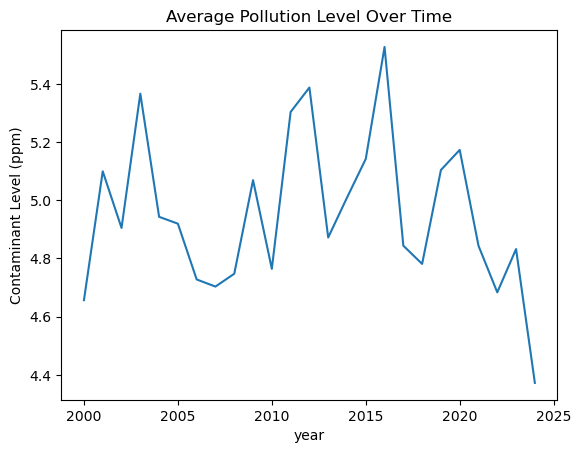

In [22]:
# Average pollution level by year
pollution_trend = df.groupby('year')['contaminant_level_ppm'].mean()
# Plotting (optional if you're using matplotlib/seaborn)
pollution_trend.plot(kind='line', title='Average Pollution Level Over Time', ylabel='Contaminant Level (ppm)')


In [23]:
# Average pollution level by region
pollution_by_region = df.groupby('region')['contaminant_level_ppm'].mean().sort_values(ascending=False)
print(pollution_by_region)


region
South      5.039672
Central    5.033273
West       4.988653
North      4.913542
East       4.804128
Name: contaminant_level_ppm, dtype: float64


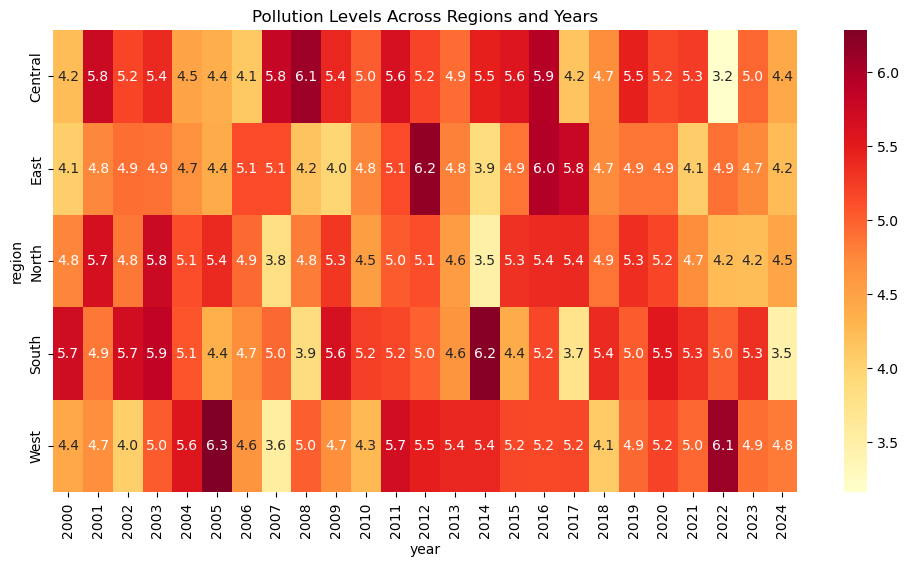

In [24]:

# Create a pivot table of average pollution levels
pivot_table = df.pivot_table(values='contaminant_level_ppm', index='region', columns='year', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title('Pollution Levels Across Regions and Years')
plt.show()


4. What is the average contaminant level ppm across all regions?

In [25]:
average_contaminant_by_region = df.groupby('region')['contaminant_level_ppm'].mean().sort_values(ascending=False)
print(average_contaminant_by_region)

region
South      5.039672
Central    5.033273
West       4.988653
North      4.913542
East       4.804128
Name: contaminant_level_ppm, dtype: float64


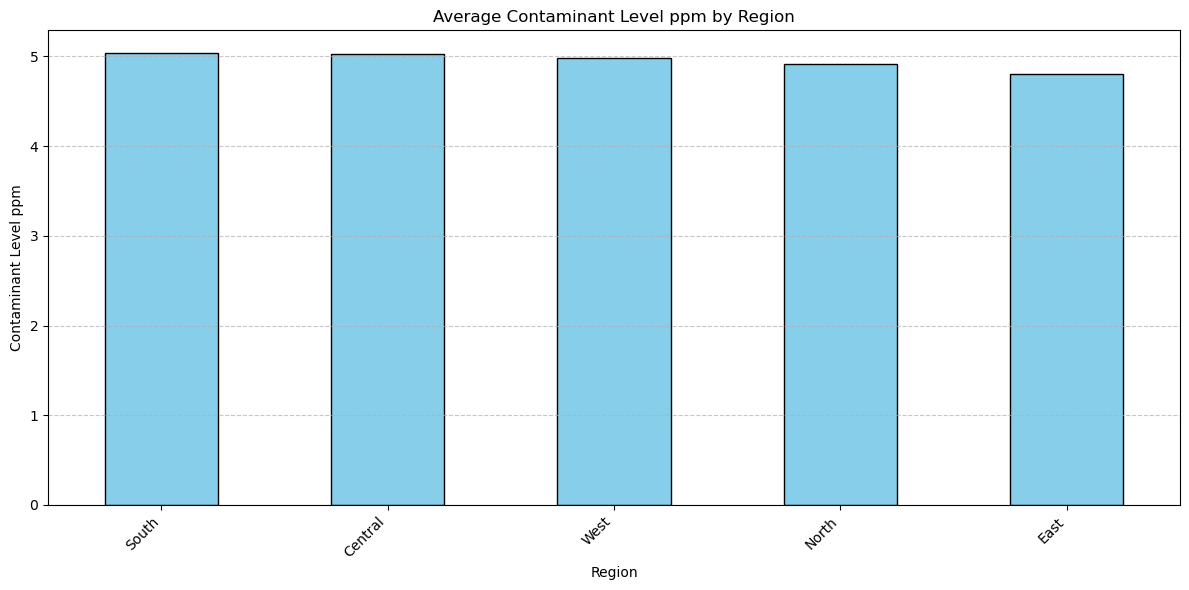

In [26]:
avg_contaminant = df.groupby('region')['contaminant_level_ppm'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_contaminant.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Contaminant Level ppm by Region')
plt.xlabel('Region')
plt.ylabel('Contaminant Level ppm')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

5. Which regions have the highest and lowest access to clean water

In [27]:
clean_water_access = df.groupby('region')['access_to_clean_water__of_population'].mean().sort_values()

# Region with lowest and highest access
lowest_access = clean_water_access.idxmin(), clean_water_access.min()
highest_access = clean_water_access.idxmax(), clean_water_access.max()

print("Lowest access:", lowest_access)
print("Highest access:", highest_access)

Lowest access: ('East', 63.250656000000006)
Highest access: ('Central', 65.4810147299509)


6. What is the average pH level of water across regions

In [28]:
# Average pH level by region
average_ph_by_region = df.groupby('region')['ph_level'].mean().sort_values()

print(average_ph_by_region)


region
Central    7.209509
East       7.231648
North      7.243169
West       7.265556
South      7.333690
Name: ph_level, dtype: float64


7. Which regions have the highest and lowest access to clean water

In [29]:
# Group by region and calculate average access to clean water
clean_water_access = df.groupby('region')['access_to_clean_water__of_population'].mean().sort_values()

# Display lowest and highest access
lowest_region = clean_water_access.idxmin()
lowest_value = clean_water_access.min()

highest_region = clean_water_access.idxmax()
highest_value = clean_water_access.max()

print(f"🔻 Lowest Access: {lowest_region} with {lowest_value:.2f}% of population")
print(f"🔺 Highest Access: {highest_region} with {highest_value:.2f}% of population")


🔻 Lowest Access: East with 63.25% of population
🔺 Highest Access: Central with 65.48% of population


8. How does turbidity vary by region or water source type?

In [30]:
# Average turbidity per region
turbidity_by_region = df.groupby('region')['turbidity_ntu'].mean().sort_values(ascending=False)
print(turbidity_by_region)


region
East       2.517968
North      2.492068
West       2.491077
Central    2.449493
South      2.447724
Name: turbidity_ntu, dtype: float64


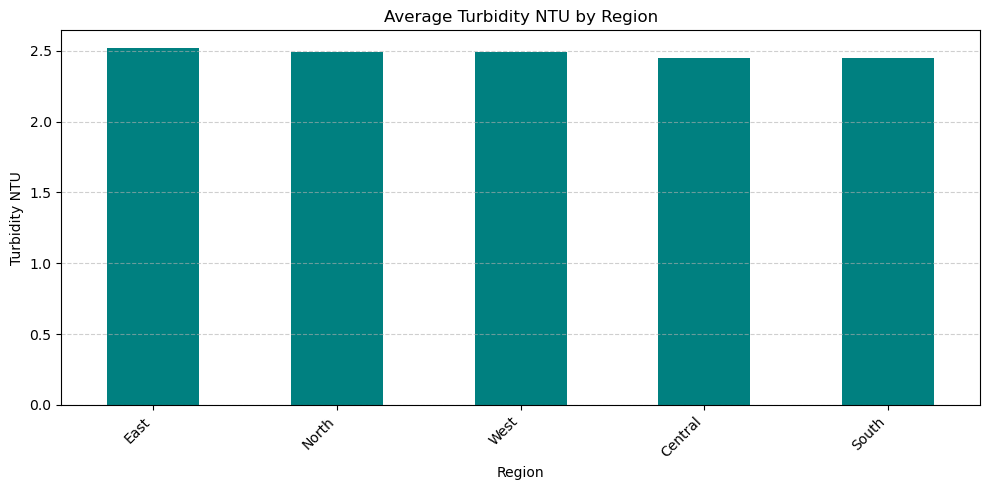

In [31]:
turbidity_by_region.plot(kind='bar', color='teal', figsize=(10, 5))
plt.title('Average Turbidity NTU by Region')
plt.ylabel('Turbidity NTU')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

9. What is the relationship between contaminant levels and reported disease cases?

In [32]:
# List of disease columns
disease_cols = [
    'diarrheal_cases_per_100,000_people',
    'cholera_cases_per_100,000_people',
    'typhoid_cases_per_100,000_people'
]

# Correlation with contaminant level
# Ensure the column names match the cleaned column names in the dataframe
disease_cols = [
    'diarrheal_cases_per_100000_people',
    'cholera_cases_per_100000_people',
    'typhoid_cases_per_100000_people'
]

# Calculate correlations
correlations = df[disease_cols + ['contaminant_level_ppm']].corr()
contaminant_corr = correlations['contaminant_level_ppm'].drop('contaminant_level_ppm')

print("Correlation between contaminant level and disease cases:")
print(contaminant_corr)


Correlation between contaminant level and disease cases:
diarrheal_cases_per_100000_people   -0.002599
cholera_cases_per_100000_people      0.027019
typhoid_cases_per_100000_people      0.020529
Name: contaminant_level_ppm, dtype: float64


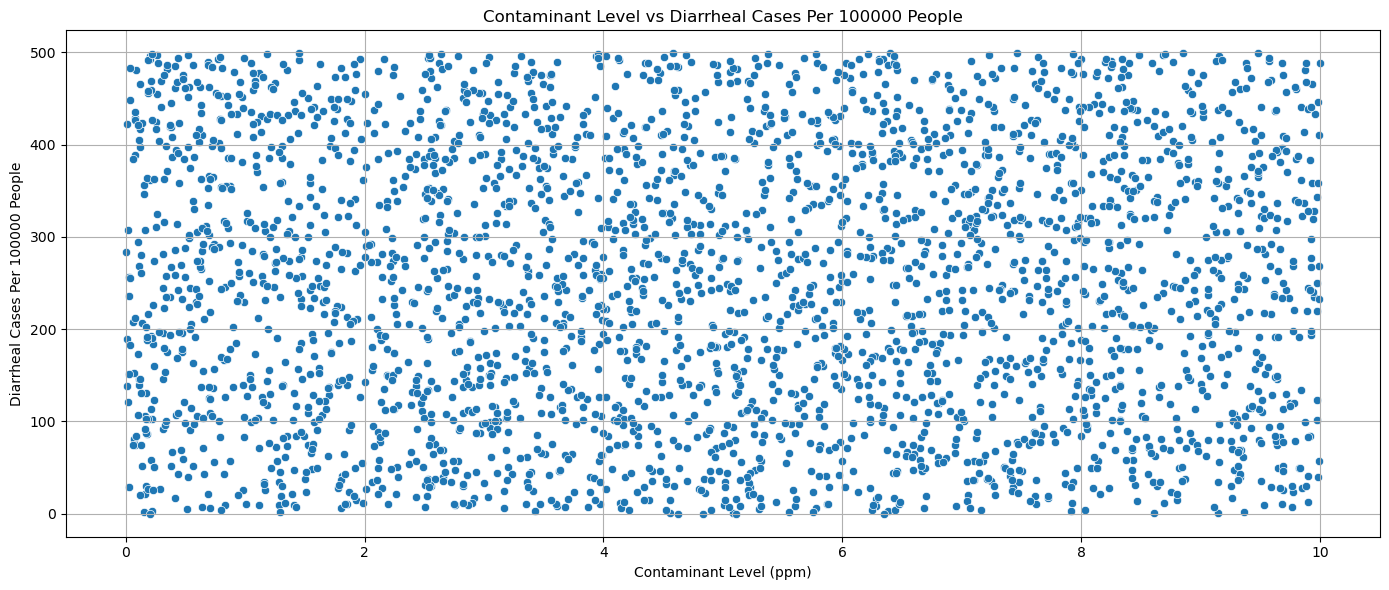

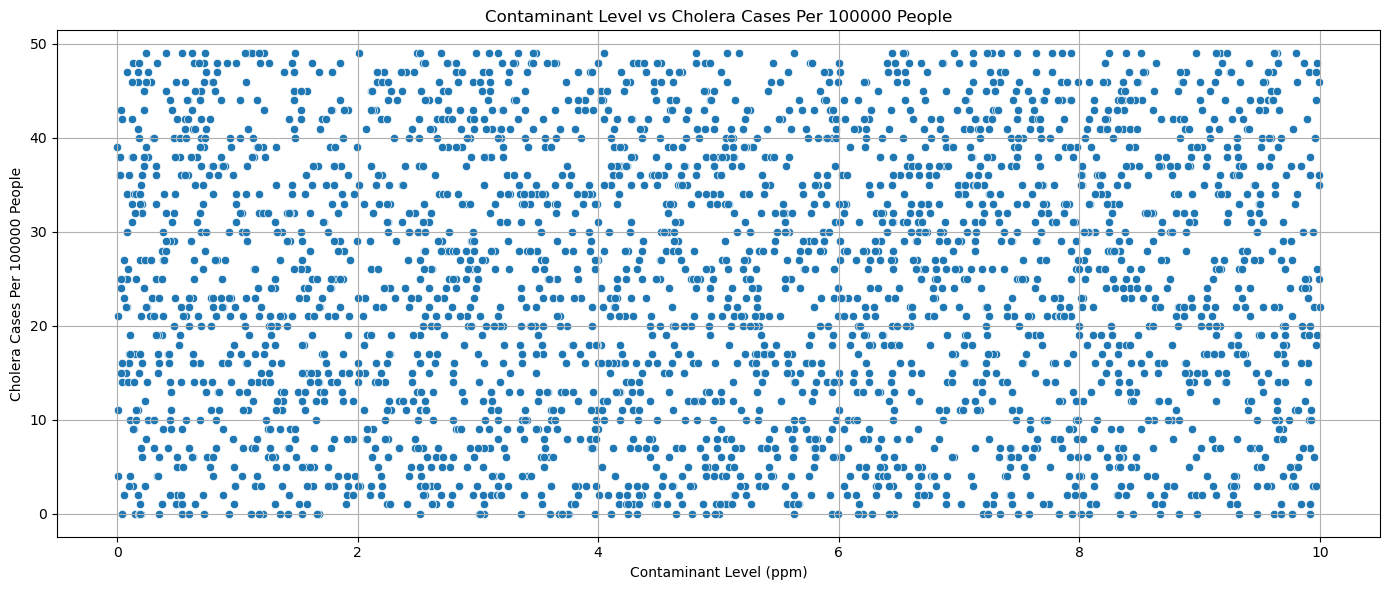

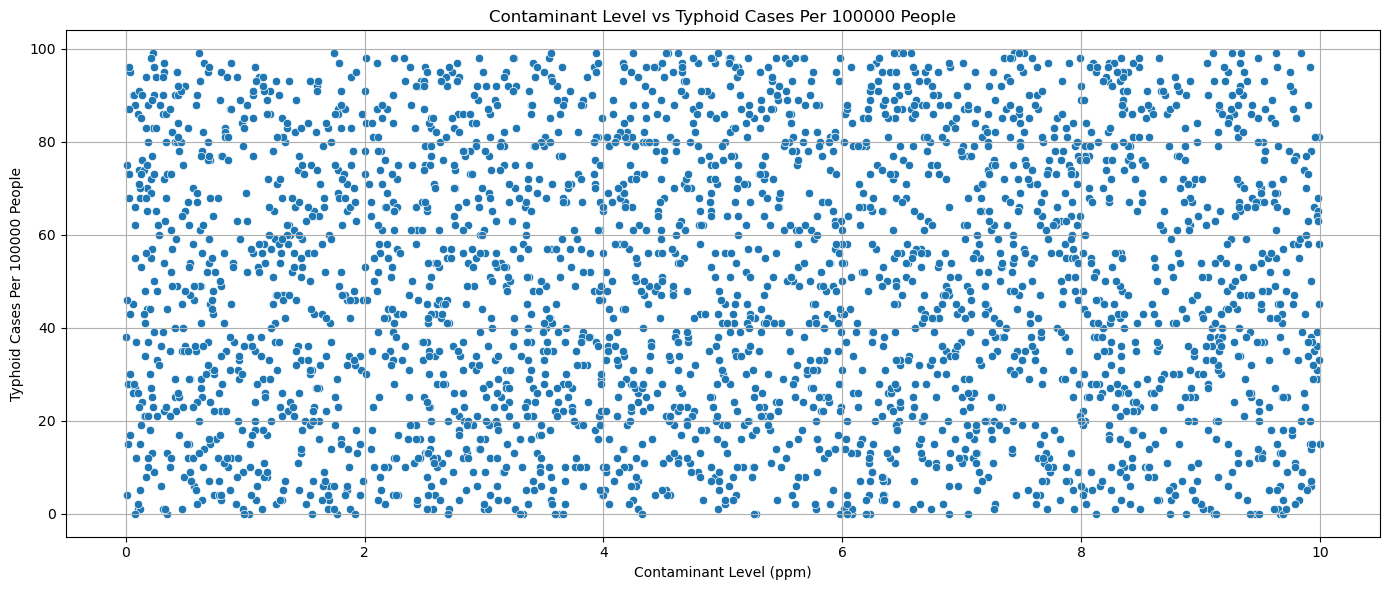

In [33]:

for disease in disease_cols:
    plt.figure(figsize=(14, 6))
    sns.scatterplot(data=df, x='contaminant_level_ppm', y=disease)
    plt.title(f'Contaminant Level vs {disease.replace("_", " ").title()}')
    plt.xlabel('Contaminant Level (ppm)')
    plt.ylabel(disease.replace('_', ' ').title())
    plt.grid(True)
    plt.tight_layout()
    plt.show()

10. Which regions have the highest infant mortality rates, and how do they relate to water quality?

In [34]:
# Average infant mortality by region
infant_mortality_by_region = df.groupby('region')['infant_mortality_rate_per_1000_live_births'].mean().sort_values(ascending=False)

print(infant_mortality_by_region)


region
Central    51.804337
East       51.635504
South      50.778776
North      50.451203
West       49.315084
Name: infant_mortality_rate_per_1000_live_births, dtype: float64


In [35]:

water_quality_cols = [
    'contaminant_level_ppm',
    'access_to_clean_water__of_population',
    'ph_level',
    'turbidity_ntu',
    'infant_mortality_rate_per_1000_live_births'
]
correlations = df[water_quality_cols].corr()
mortality_corr = correlations['infant_mortality_rate_per_1000_live_births'].drop('infant_mortality_rate_per_1000_live_births')

print("Correlation between water quality and infant mortality:")
print(mortality_corr)


Correlation between water quality and infant mortality:
contaminant_level_ppm                  -0.028094
access_to_clean_water__of_population    0.027276
ph_level                                0.004177
turbidity_ntu                           0.006440
Name: infant_mortality_rate_per_1000_live_births, dtype: float64


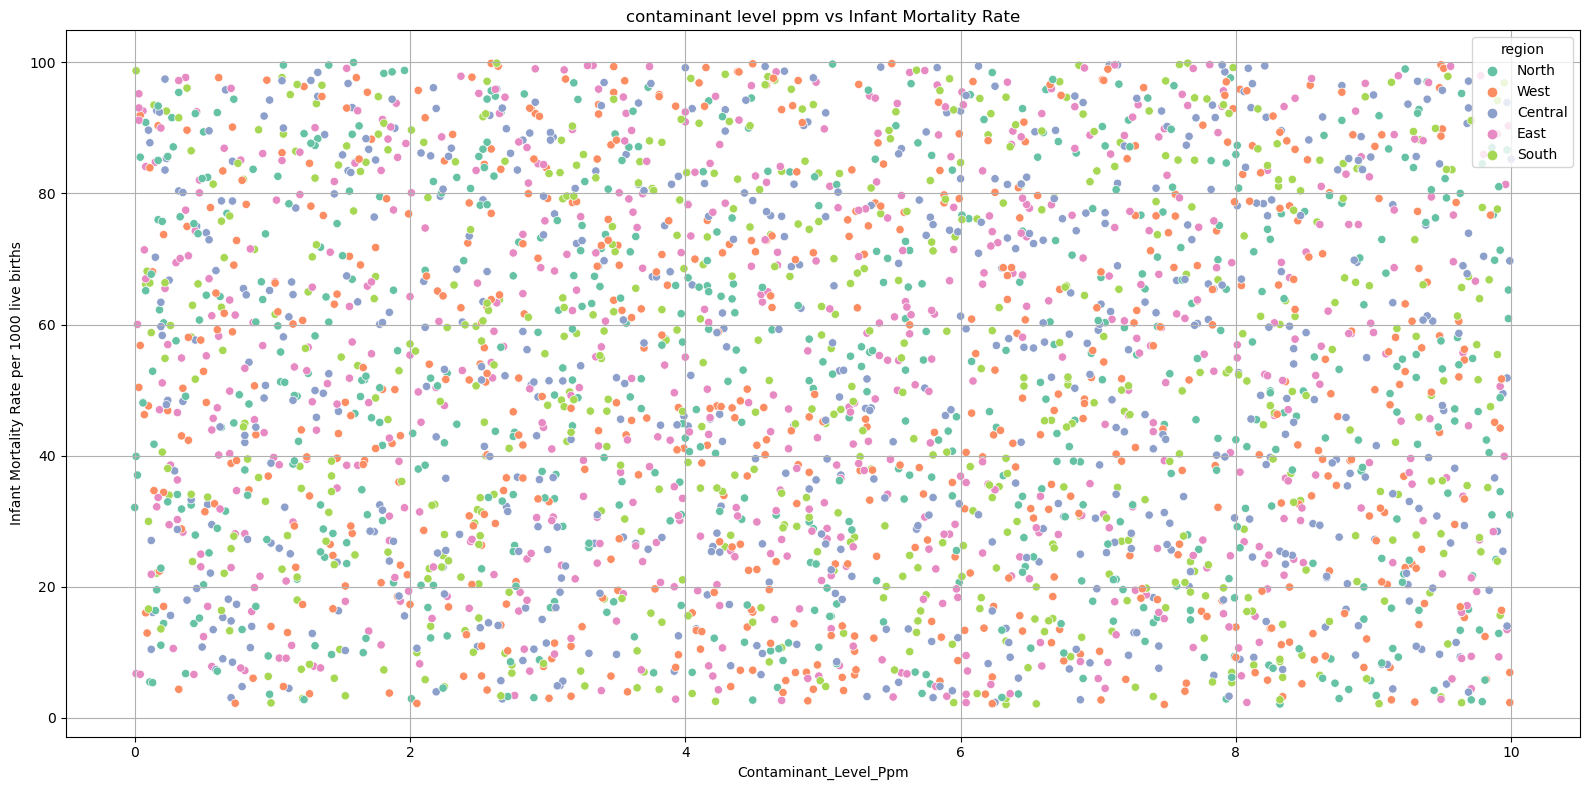

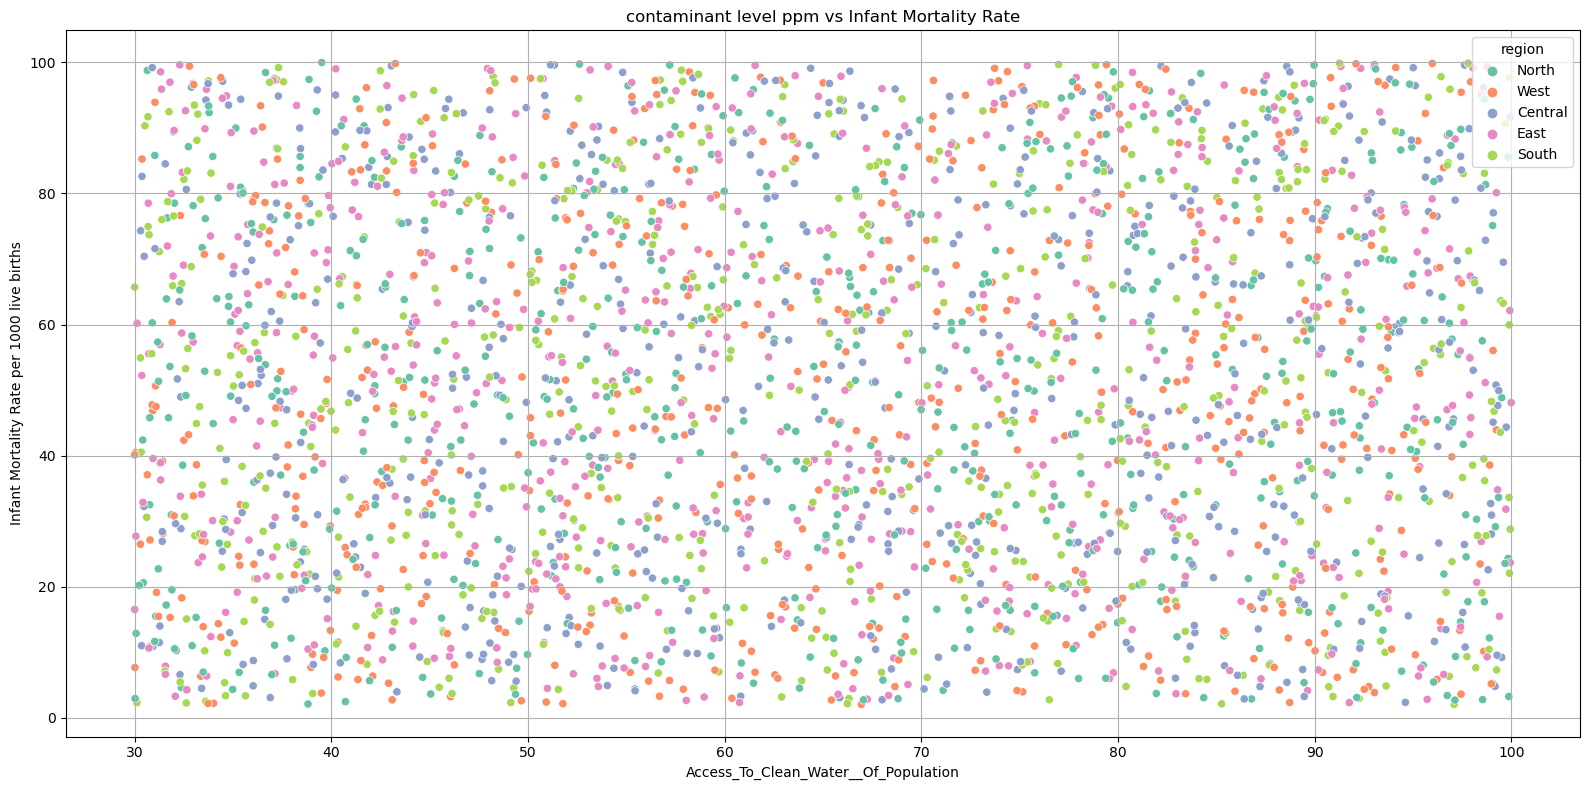

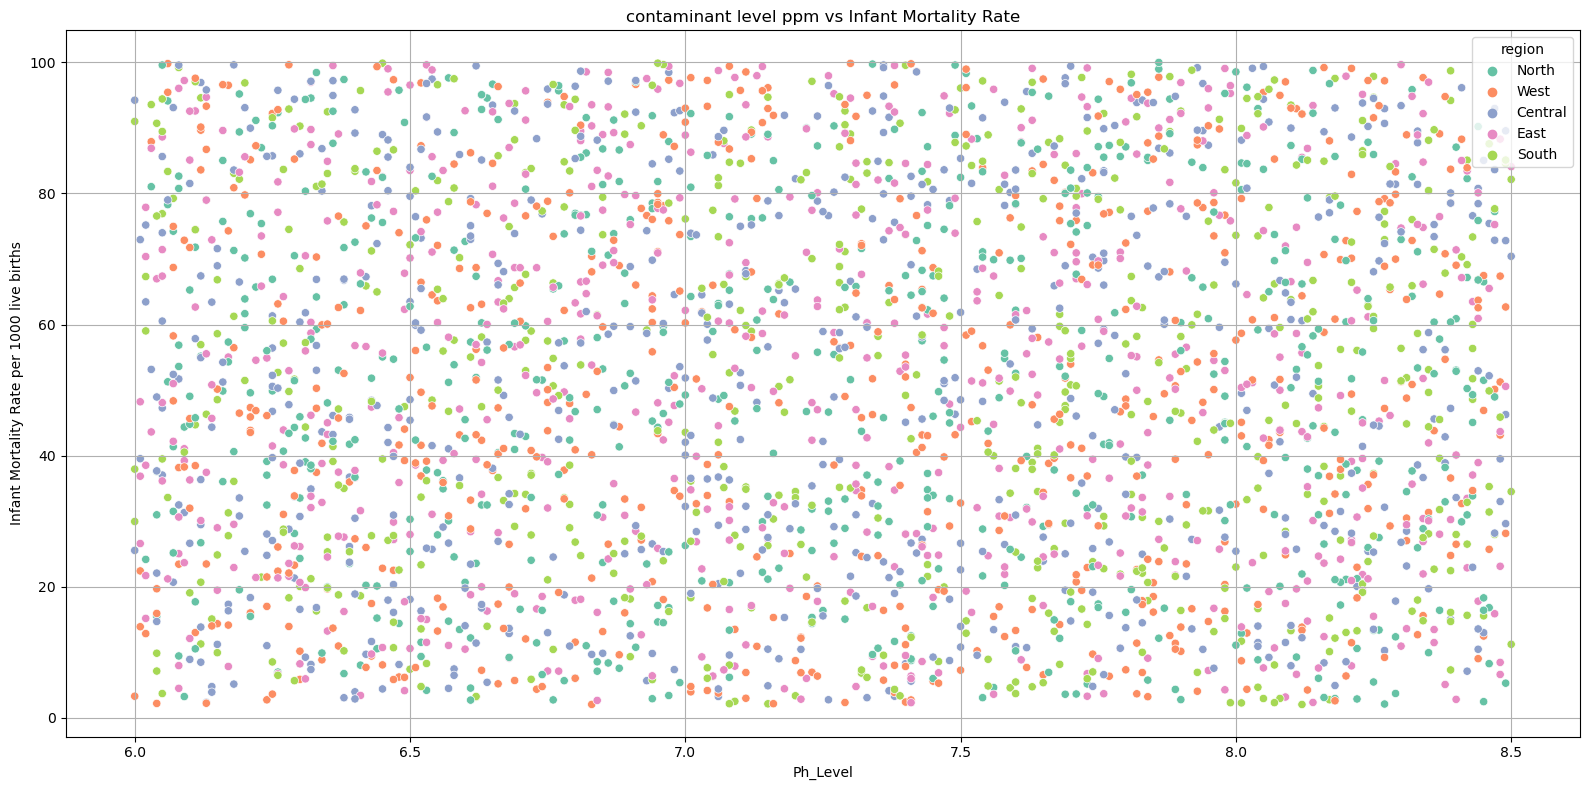

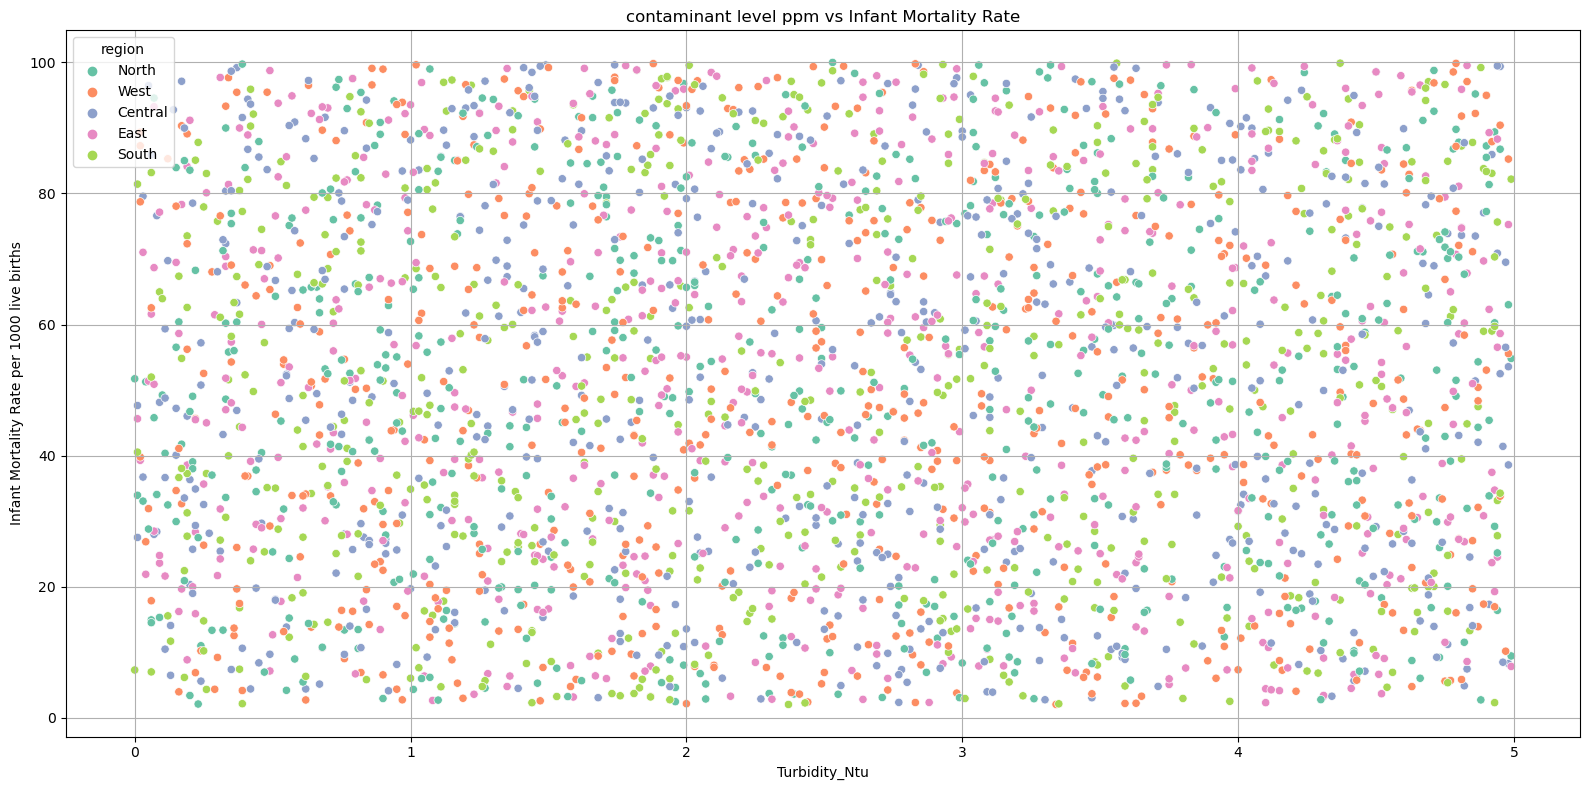

In [36]:
water_quality_vars = [
    'contaminant_level_ppm',
    'access_to_clean_water__of_population',
    'ph_level',
    'turbidity_ntu'
]

# Create scatter plots for each water quality variable
for var in water_quality_vars:
    plt.figure(figsize=(16, 8))
    sns.scatterplot(
        data=df,
        x=var,
        y='infant_mortality_rate_per_1000_live_births',
        hue='region',
        palette='Set2'
    )
    plt.title('contaminant level ppm vs Infant Mortality Rate')
    plt.xlabel(var.title())
    plt.ylabel('Infant Mortality Rate per 1000 live births')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

11. How have pollution levels changed over time?

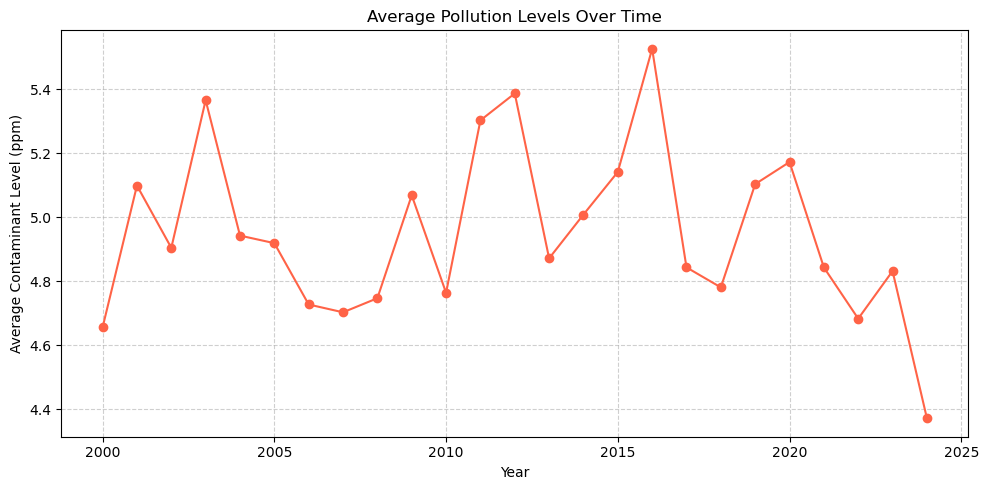

In [37]:
# Group by year and calculate average contaminant level
pollution_over_time = df.groupby('year')['contaminant_level_ppm'].mean()

# Plot the trend
plt.figure(figsize=(10, 5))
pollution_over_time.plot(marker='o', linestyle='-', color='tomato')
plt.title('Average Pollution Levels Over Time')
plt.xlabel('Year')
plt.ylabel('Average Contaminant Level (ppm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

12. Are there seasonal or yearly trends in disease incidence?

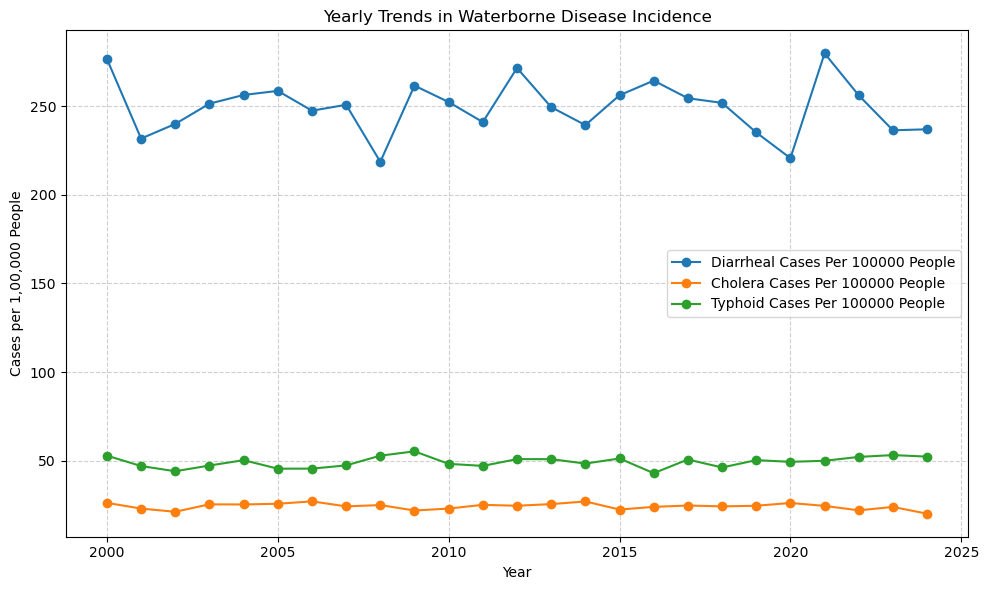

In [38]:
disease_trends = df.groupby('year')[[
    'diarrheal_cases_per_100000_people',
    'cholera_cases_per_100000_people',
    'typhoid_cases_per_100000_people'
]].mean()

# Plotting all three diseases on the same graph
plt.figure(figsize=(10, 6))
for col in disease_trends.columns:
    plt.plot(disease_trends.index, disease_trends[col], marker='o', label=col.replace('_', ' ').title())

plt.title('Yearly Trends in Waterborne Disease Incidence')
plt.xlabel('Year')
plt.ylabel('Cases per 1,00,000 People')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

13. Is there a relationship between GDP per capita and pollution levels?

In [39]:
correlation = df['gdp_per_capita_usd'].corr(df['contaminant_level_ppm'])
print(f"Correlation between GDP per capita and pollution levels: {correlation:.2f}")

Correlation between GDP per capita and pollution levels: -0.02


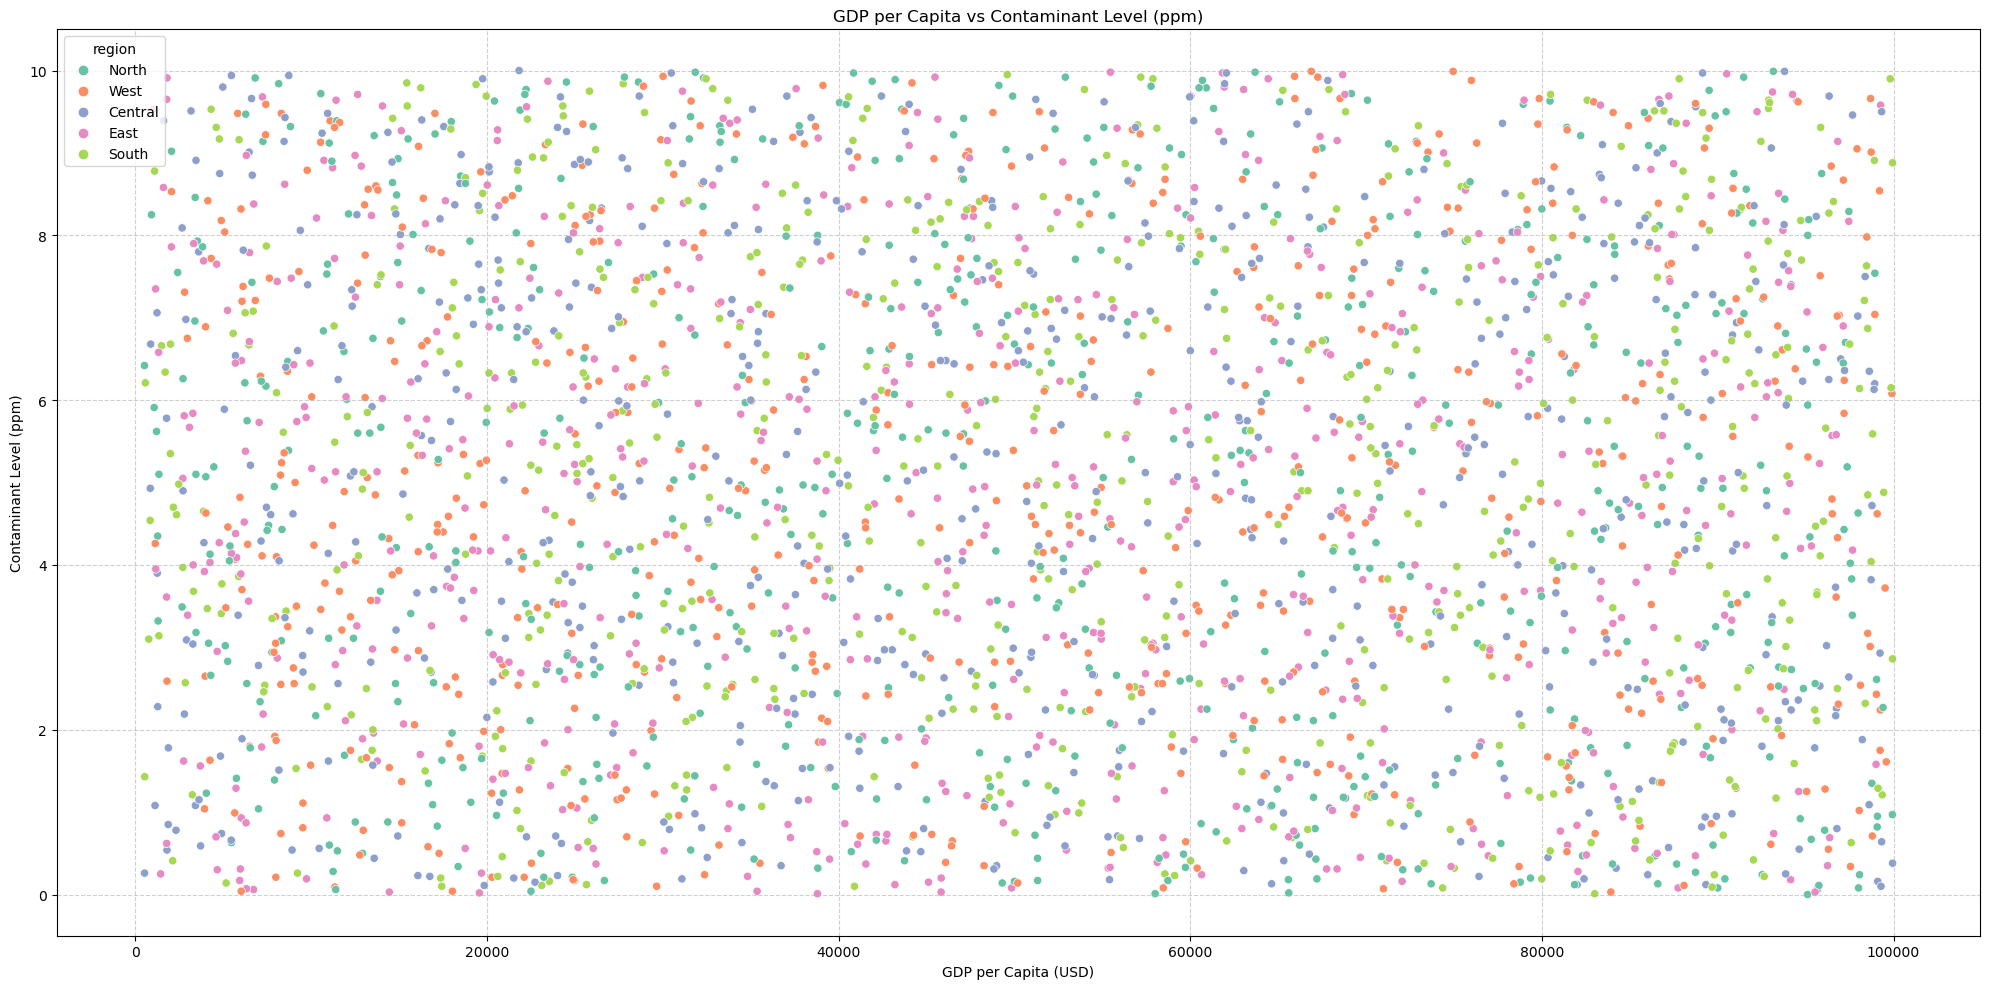

In [40]:

plt.figure(figsize=(20, 10))
sns.scatterplot(
    data=df,
    x='gdp_per_capita_usd',
    y='contaminant_level_ppm',
    hue='region',
    palette='Set2'
)
plt.title('GDP per Capita vs Contaminant Level (ppm)')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Contaminant Level (ppm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

14. Does urbanization rate impact access to clean water or pollution severity?

In [41]:
# Correlation between urbanization and clean water access
corr_clean = df['urbanization_rate_'].corr(df['access_to_clean_water__of_population'])

# Correlation between urbanization and pollution level
corr_pollution = df['urbanization_rate_'].corr(df['contaminant_level_ppm'])

print(f"Correlation (Urbanization ↔ Clean Water Access): {corr_clean:.2f}")
print(f"Correlation (Urbanization ↔ Pollution Level): {corr_pollution:.2f}")


Correlation (Urbanization ↔ Clean Water Access): -0.02
Correlation (Urbanization ↔ Pollution Level): 0.00


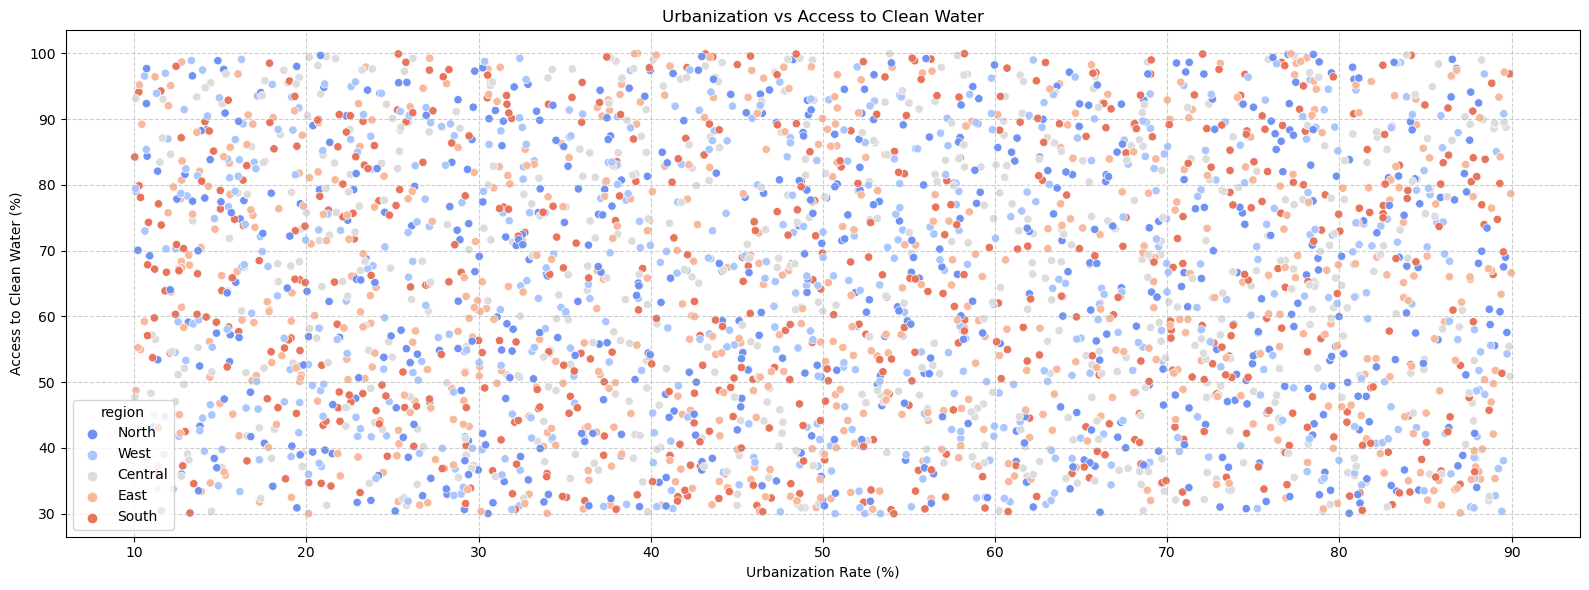

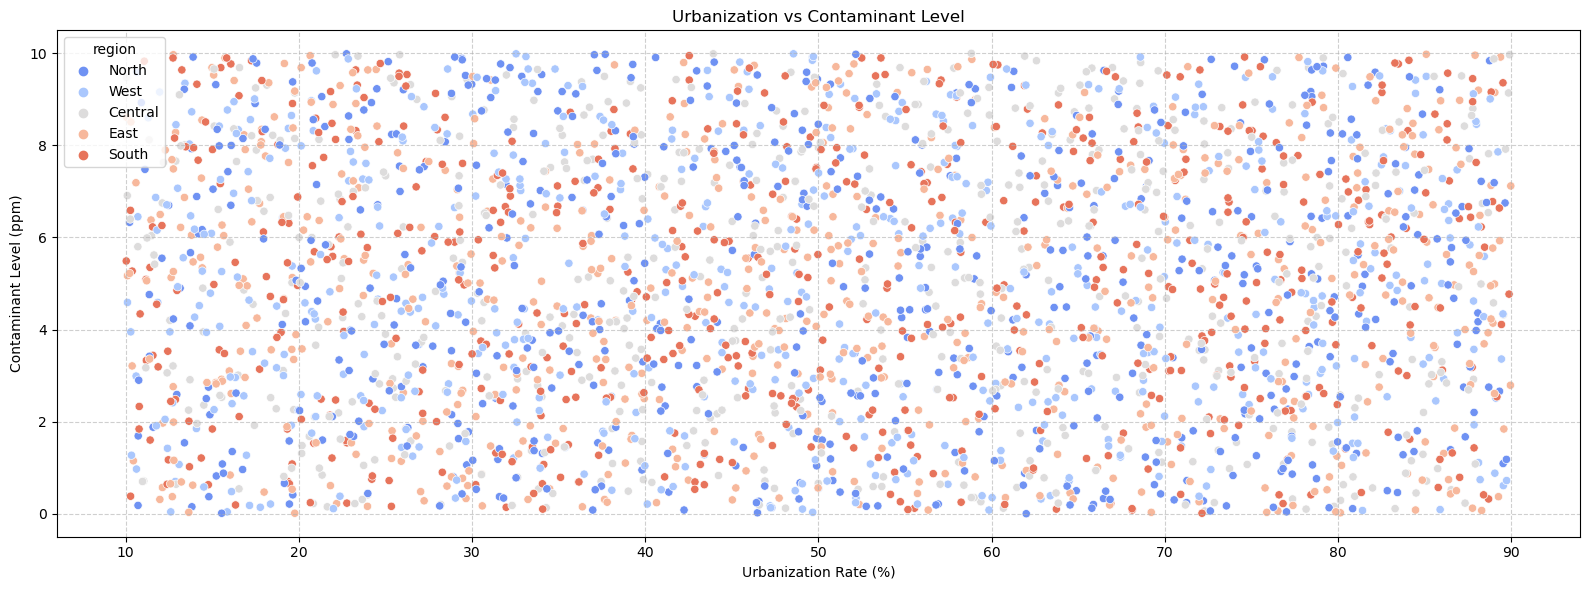

In [45]:
# Urbanization vs Clean Water Access
plt.figure(figsize=(16, 6))
sns.scatterplot(data=df,
                x='urbanization_rate_',
                y='access_to_clean_water__of_population',
                hue='region', palette='coolwarm')
plt.title('Urbanization vs Access to Clean Water')
plt.xlabel('Urbanization Rate (%)')
plt.ylabel('Access to Clean Water (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Urbanization vs Pollution Level
plt.figure(figsize=(16, 6))
sns.scatterplot(data=df,
                x='urbanization_rate_',
                y='contaminant_level_ppm',
                hue='region', palette='coolwarm')
plt.title('Urbanization vs Contaminant Level')
plt.xlabel('Urbanization Rate (%)')
plt.ylabel('Contaminant Level (ppm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

15. How does population density affect disease spread or pollution?

In [50]:
# Correlation between population density and disease + pollution indicators
disease_cols = [
    'diarrheal_cases_per_100000_people',
    'cholera_cases_per_100000_people',
    'typhoid_cases_per_100,000_people',
    'contaminant_level_(ppm)'
]

# Correct the column names to match the cleaned column names in the dataframe
disease_cols = [
    'diarrheal_cases_per_100000_people',
    'cholera_cases_per_100000_people',
    'typhoid_cases_per_100000_people',
    'contaminant_level_ppm' 
]

correlations = df[disease_cols + ['population_density_people_per_km']].corr()  
pop_density_corr = correlations['population_density_people_per_km'].drop('population_density_people_per_km')

print("Correlation between population density and disease/pollution:")
print(pop_density_corr)


Correlation between population density and disease/pollution:
diarrheal_cases_per_100000_people    0.006277
cholera_cases_per_100000_people     -0.002469
typhoid_cases_per_100000_people      0.016777
contaminant_level_ppm               -0.005532
Name: population_density_people_per_km, dtype: float64


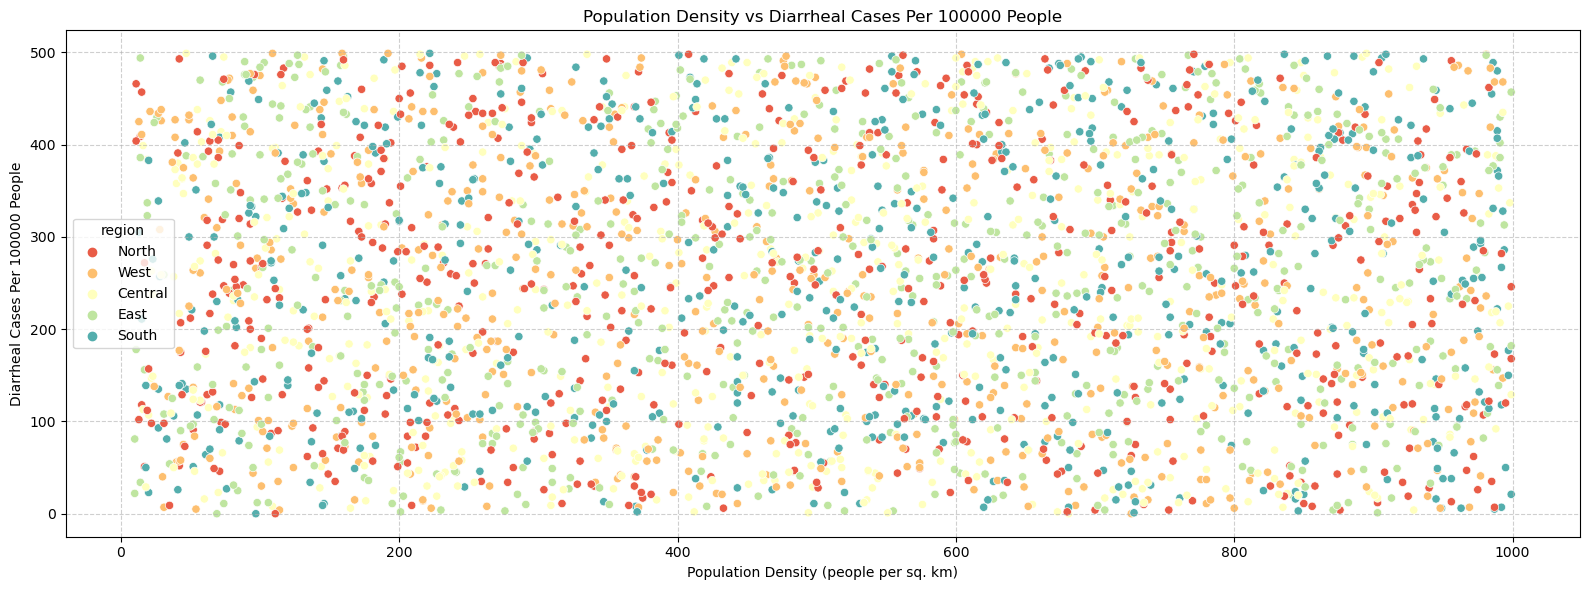

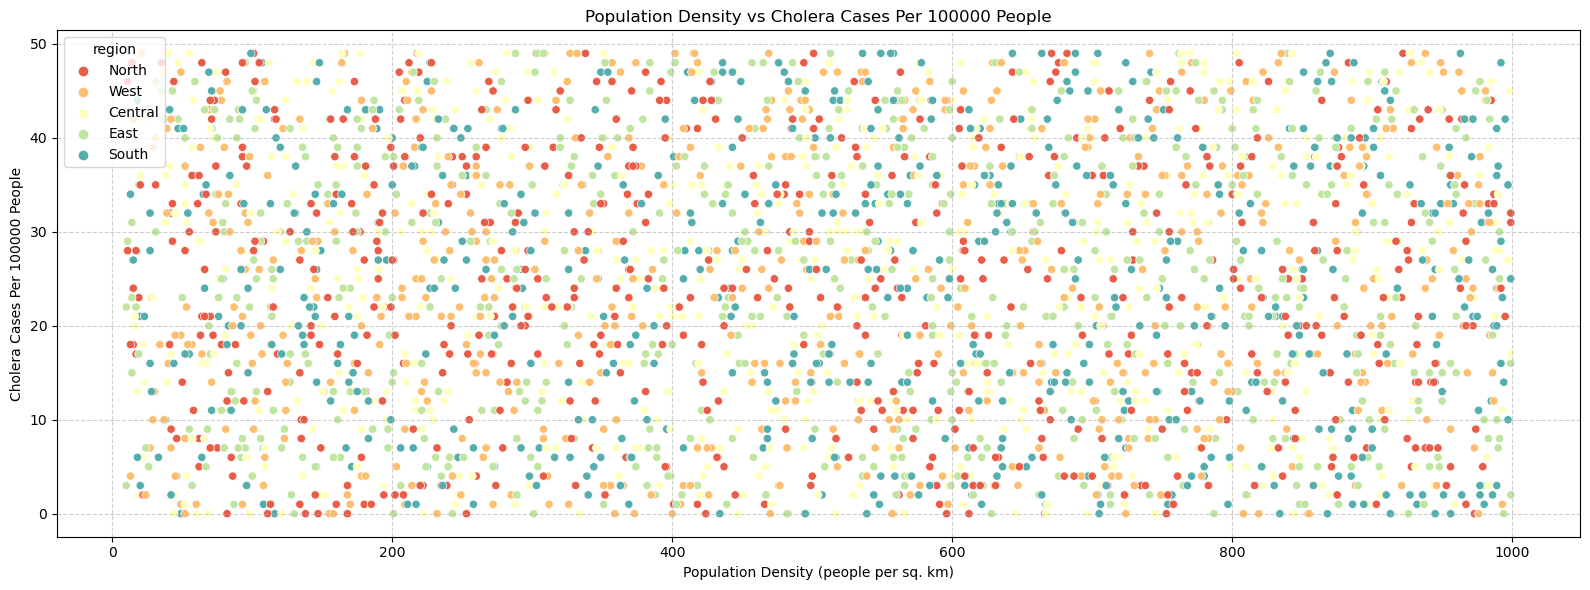

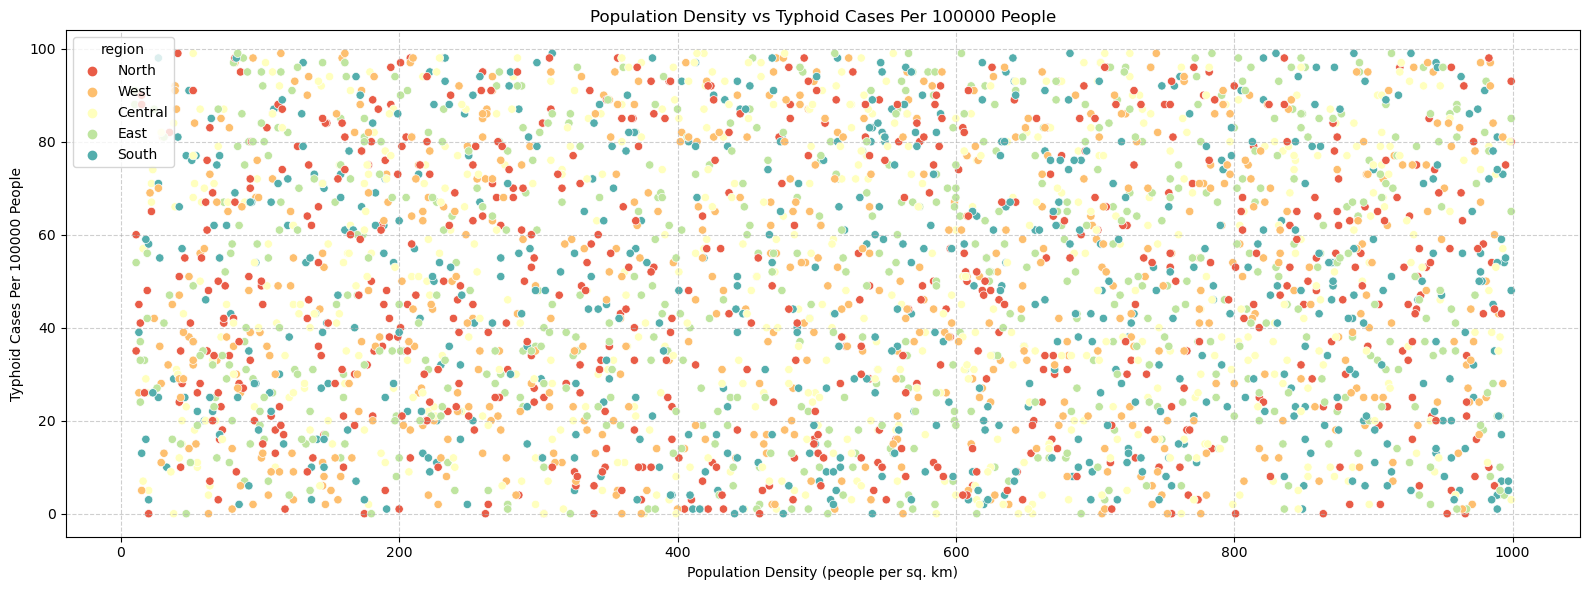

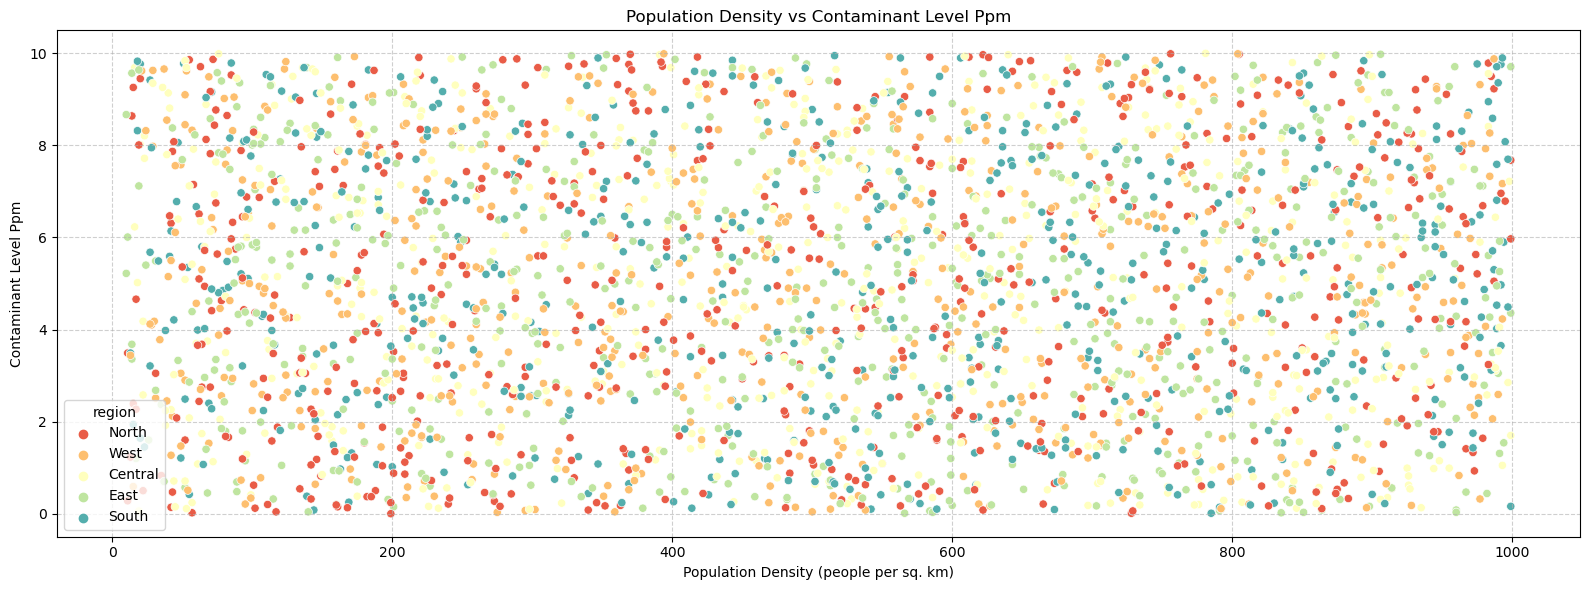

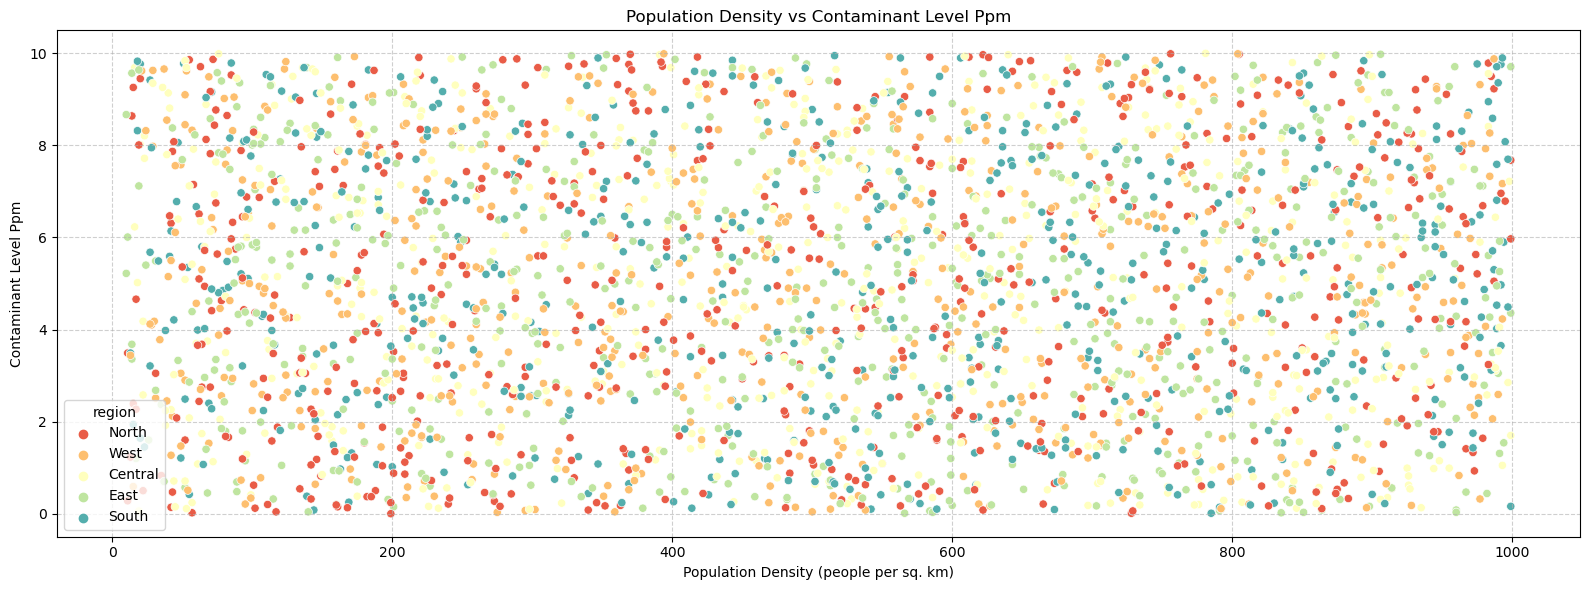

In [54]:
# Disease and pollution indicators
metrics = disease_cols + ['contaminant_level_ppm']

# Generate scatter plots
for col in metrics:
    plt.figure(figsize=(16, 6))
    sns.scatterplot(data=df,
                    x='population_density_people_per_km',
                    y=col,
                    hue='region',
                    palette='Spectral')
    plt.title(f'Population Density vs {col.replace("_", " ").title()}')
    plt.xlabel('Population Density (people per sq. km)')
    plt.ylabel(col.replace('_', ' ').title())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## Project Summary

This project involves analyzing a comprehensive dataset to explore the relationship between water quality, pollution levels, socio-economic factors, and health outcomes. The dataset includes information on water quality metrics, disease incidence, socio-economic indicators, and regional data. The key objectives of this analysis are:

1. **Water Quality Analysis**:
    - Investigating metrics such as contaminant levels (ppm), pH, turbidity (NTU), and access to clean water.
    - Identifying regions with the highest and lowest water quality.

2. **Health Impacts**:
    - Analyzing the prevalence of waterborne diseases such as diarrhea, cholera, and typhoid.
    - Exploring the correlation between water quality and infant mortality rates.

3. **Socio-Economic Factors**:
    - Examining the relationship between GDP per capita, urbanization rate, and access to clean water.
    - Assessing the impact of population density on disease spread and pollution severity.

4. **Temporal and Regional Trends**:
    - Tracking changes in pollution levels and disease incidence over time.
    - Comparing water quality and health outcomes across different regions.

5. **Visualization and Insights**:
    - Utilizing visualizations such as bar plots, scatter plots, and heatmaps to uncover trends and correlations.
    - Highlighting regions and populations most at risk to guide policy and intervention strategies.

The findings aim to provide actionable insights for improving water quality, reducing health risks, and addressing socio-economic disparities.